
# Step 1: Importing Required Libraries


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D

import numpy as np


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Step 2: Load and Preprocess Dataset

In [ ]:
data = pd.read_csv('News.csv', index_col=0)
data = data.drop(["title", "subject", "date"], axis=1)
data = data.sample(frac=1, random_state=42)  # shuffle
data.reset_index(inplace=True)
data.drop(["index"], axis=1, inplace=True)

def preprocess_text(text_data):
    preprocessed_text = []
    for sentence in tqdm(text_data):
        sentence = re.sub(r'[^\w\s]', '', sentence)  # remove punctuations
        preprocessed_text.append(' '.join(
            token.lower() for token in str(sentence).split()
            if token not in stopwords.words('english')
        ))
    return preprocessed_text

preprocessed_review = preprocess_text(data['text'].values)
data['text'] = preprocessed_review


100%|██████████| 44919/44919 [28:44<00:00, 26.04it/s]


# Step 3: Word Clouds Visualization

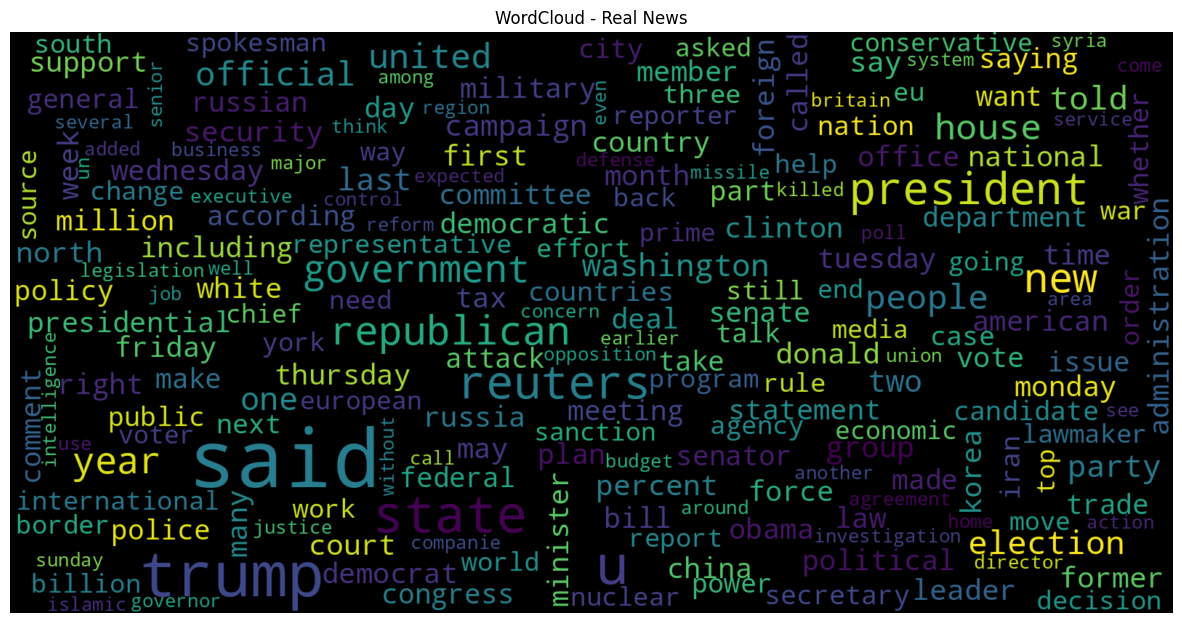

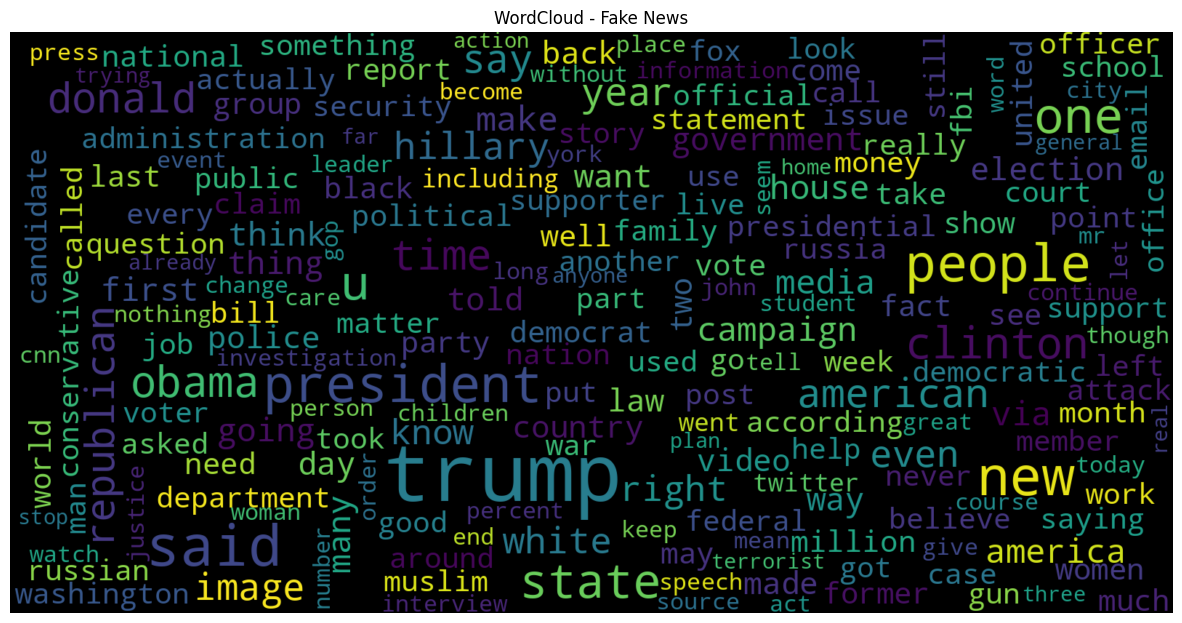

In [ ]:

# Real News
consolidated_real = ' '.join(word for word in data['text'][data['class'] == 1].astype(str))
wordCloud_real = WordCloud(width=1600, height=800, random_state=21, max_font_size=110, collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud_real.generate(consolidated_real), interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Real News")
plt.show()

# Fake News
consolidated_fake = ' '.join(word for word in data['text'][data['class'] == 0].astype(str))
wordCloud_fake = WordCloud(width=1600, height=800, random_state=21, max_font_size=110, collocations=False)
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud_fake.generate(consolidated_fake), interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Fake News")
plt.show()



# Step 4: Top Common Words

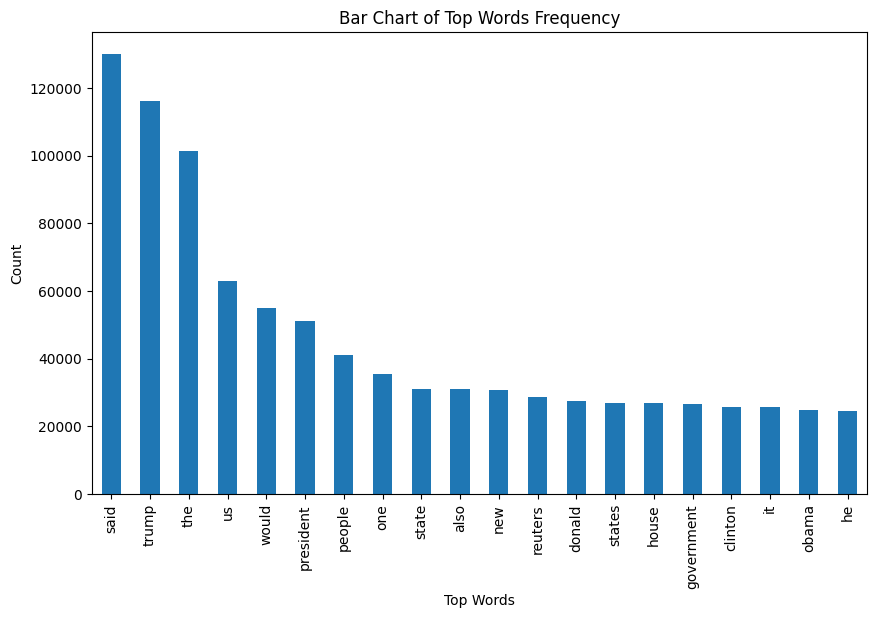

In [ ]:


def get_top_n_words(corpus, n=None):
    vec = CountVectorizer().fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

common_words = get_top_n_words(data['text'], 20)
df1 = pd.DataFrame(common_words, columns=['Word', 'Count'])

df1.groupby('Word').sum()['Count'].sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 6),
    xlabel="Top Words", ylabel="Count",
    title="Bar Chart of Top Words Frequency"
)
plt.show()


# Step 5: Extra Visualizations

/tmp/ipython-input-1512398888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=data, palette="coolwarm")


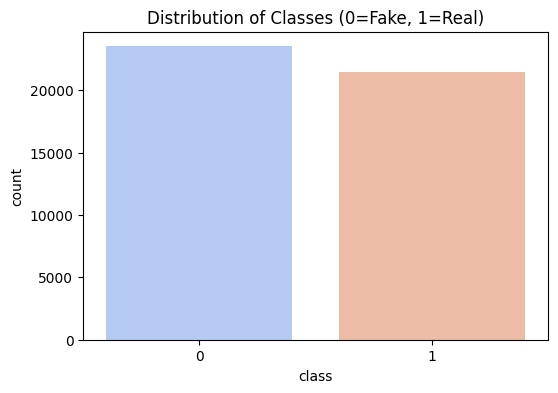

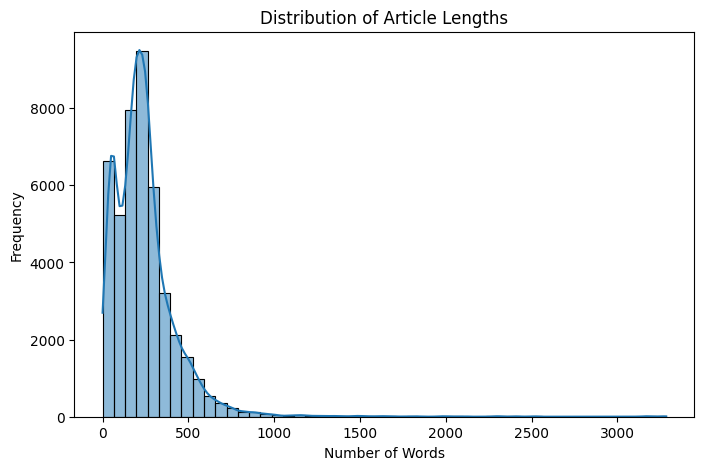

In [ ]:

# 1) Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="class", data=data, palette="coolwarm")
plt.title("Distribution of Classes (0=Fake, 1=Real)")
plt.show()

# 2) Distribution of Article Lengths
data['text_length'] = data['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='text_length', bins=50, kde=True)
plt.title("Distribution of Article Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


# Step 6: Most Important Features

/tmp/ipython-input-3016499386.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Coefficient", y="Word", palette="viridis")


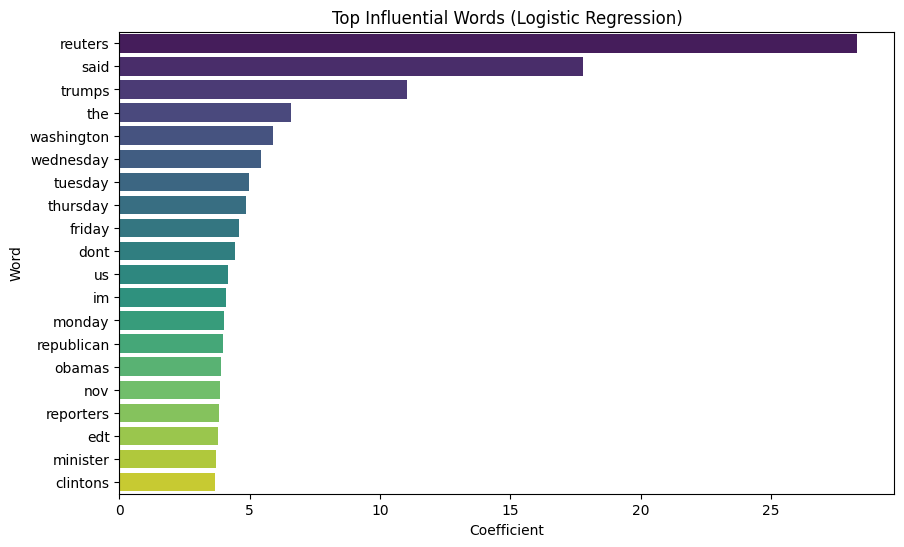

In [ ]:

vectorizer_tmp = TfidfVectorizer(max_features=5000)
X_tmp = vectorizer_tmp.fit_transform(data['text'])
y_tmp = data['class']

model_tmp = LogisticRegression(max_iter=200)
model_tmp.fit(X_tmp, y_tmp)

feature_names = vectorizer_tmp.get_feature_names_out()
coefficients = model_tmp.coef_[0]
top_features = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Coefficient", y="Word", palette="viridis")
plt.title("Top Influential Words (Logistic Regression)")
plt.show()


# Step 7: Heatmap of Word Correlations

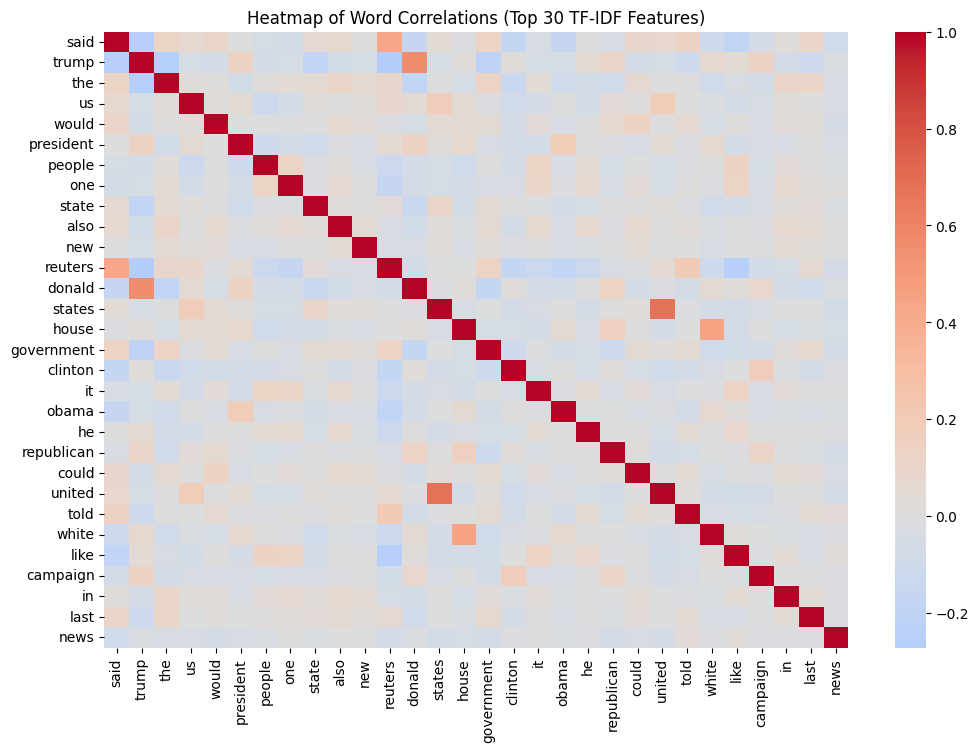

In [ ]:

top_n = 30
common_words = get_top_n_words(data['text'], n=top_n)
top_words = [w for w, c in common_words]

vectorizer_top = TfidfVectorizer(vocabulary=top_words)
X_top = vectorizer_top.fit_transform(data['text']).toarray()
corr_matrix = np.corrcoef(X_top, rowvar=False)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, xticklabels=top_words, yticklabels=top_words, cmap="coolwarm", center=0)
plt.title("Heatmap of Word Correlations (Top 30 TF-IDF Features)")
plt.show()


# Step 8: Machine Learning Models

Logistic Regression Accuracy (Train): 0.9936477782065363
Logistic Regression Accuracy (Test): 0.9894033837934105
Random Forest Accuracy (Train): 0.9999703167205913
Random Forest Accuracy (Test): 0.9910062333036509


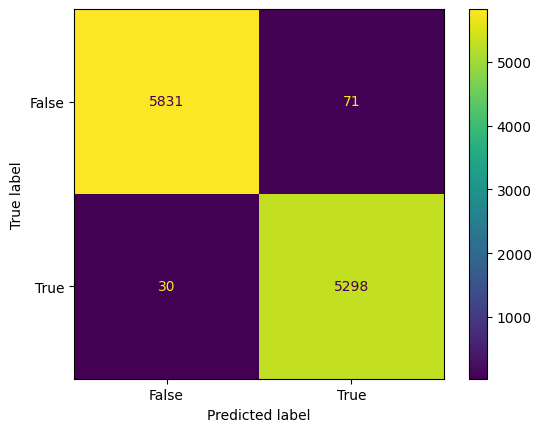

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(
    data['text'], data['class'], test_size=0.25, random_state=42
)

vectorization = TfidfVectorizer()
x_train_tfidf = vectorization.fit_transform(x_train)
x_test_tfidf = vectorization.transform(x_test)

# Logistic Regression
model_lr = LogisticRegression(max_iter=200)
model_lr.fit(x_train_tfidf, y_train)
print("Logistic Regression Accuracy (Train):", accuracy_score(y_train, model_lr.predict(x_train_tfidf)))
print("Logistic Regression Accuracy (Test):", accuracy_score(y_test, model_lr.predict(x_test_tfidf)))

# Random Forest
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(x_train_tfidf, y_train)
print("Random Forest Accuracy (Train):", accuracy_score(y_train, model_rf.predict(x_train_tfidf)))
print("Random Forest Accuracy (Test):", accuracy_score(y_test, model_rf.predict(x_test_tfidf)))

# Confusion Matrix
cm = metrics.confusion_matrix(y_test, model_rf.predict(x_test_tfidf))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[False, True])
cm_display.plot()
plt.show()


# Step 9: Deep Learning Models (LSTM & CNN)

In [ ]:

# Tokenization
max_words = 50000
max_len = 500

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data['text'])
X_seq = tokenizer.texts_to_sequences(data['text'])
X_pad = pad_sequences(X_seq, maxlen=max_len)

# Split for DL
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, data['class'], test_size=0.25, random_state=42
)

# -------------------- LSTM Model --------------------
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining LSTM model...")
history_lstm = lstm_model.fit(
    X_train_dl, y_train_dl,
    epochs=3, batch_size=64,
    validation_data=(X_test_dl, y_test_dl), verbose=1
)

loss, accuracy = lstm_model.evaluate(X_test_dl, y_test_dl, verbose=0)
print("LSTM Accuracy (Test):", accuracy)

# -------------------- CNN Model --------------------
cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining CNN model...")
history_cnn = cnn_model.fit(
    X_train_dl, y_train_dl,
    epochs=3, batch_size=64,
    validation_data=(X_test_dl, y_test_dl), verbose=1
)

loss_cnn, accuracy_cnn = cnn_model.evaluate(X_test_dl, y_test_dl, verbose=0)
print("CNN Accuracy (Test):", accuracy_cnn)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training LSTM model...
Epoch 1/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 811s 2s/step - accuracy: 0.8924 - loss: 0.2641 - val_accuracy: 0.9843 - val_loss: 0.0494
Epoch 2/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 878s 2s/step - accuracy: 0.9847 - loss: 0.0470 - val_accuracy: 0.9838 - val_loss: 0.0546
Epoch 3/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 841s 2s/step - accuracy: 0.9960 - loss: 0.0155 - val_accuracy: 0.9900 - val_loss: 0.0421
LSTM Accuracy (Test): 0.9900267124176025

Training CNN model...
Epoch 1/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 309s 582ms/step - accuracy: 0.9036 - loss: 0.2234 - val_accuracy: 0.9958 - val_loss: 0.0130
Epoch 2/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 282s 536ms/step - accuracy: 0.9966 - loss: 0.0129 - val_accuracy: 0.9976 - val_loss: 0.0078
Epoch 3/3
527/527 ━━━━━━━━━━━━━━━━━━━━ 327s 545ms/step - accuracy: 0.9994 - loss: 0.0030 - val_accuracy: 0.9982 - val_loss: 0.0064
CNN Accuracy (Test): 0.9982190728187561


# Step 10: Compare DL Models

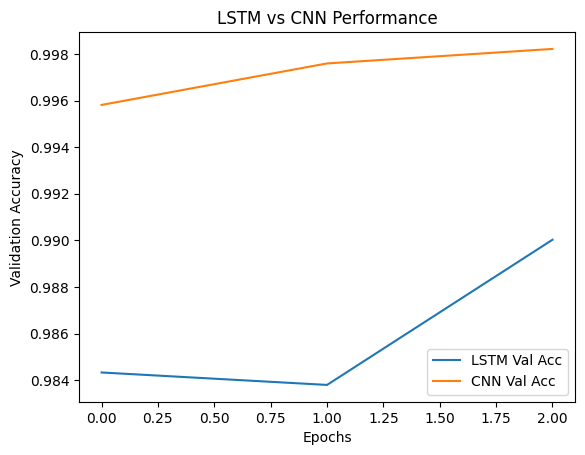

In [ ]:

plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Acc')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('LSTM vs CNN Performance')
plt.legend()
plt.show()
